<a href="https://colab.research.google.com/github/susmitsingh01/triton-llm-kernels-lab/blob/main/triton-lab-notebook-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/triton-llm-kernels-lab'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots', '01_triton_fundamentals')

os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory : {BASE_DIR}')
print(f'Plots directory: {PLOTS_DIR}')

Mounted at /content/drive
Base directory : /content/drive/MyDrive/triton-llm-kernels-lab
Plots directory: /content/drive/MyDrive/triton-llm-kernels-lab/plots/01_triton_fundamentals


In [1]:
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt
import time

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU : Tesla T4
VRAM: 15.6 GB


## Section 1: Vector Addition

The simplest Triton kernel and the foundation of everything that follows.

Each program instance handles a fixed block of elements: it computes its position in the array, loads its chunk, adds, and stores back. This establishes the skeleton — `program_id → offsets → mask → load → compute → store` — that every subsequent kernel in this notebook reuses.

In [2]:
@triton.jit
def vector_add_kernel(
    x_ptr,           # pointer to input vector x
    y_ptr,           # pointer to input vector y
    out_ptr,         # pointer to output vector
    n_elements,      # total number of elements
    BLOCK_SIZE: tl.constexpr,  # number of elements per program instance
):
    pid = tl.program_id(axis=0)                        # which block am I
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)  # indices for my block
    mask = offsets < n_elements                         # guard against out-of-bounds

    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)

    tl.store(out_ptr + offsets, x + y, mask=mask)


def vector_add(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    out = torch.empty_like(x)
    n_elements = x.numel()
    # ceil division ensures the last partial block is not dropped
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    vector_add_kernel[grid](x, y, out, n_elements, BLOCK_SIZE=1024)
    return out

### Correctness Check
Compare Triton output against PyTorch to verify the kernel is correct before benchmarking.

In [19]:
torch.manual_seed(0)
n = 10_000_000
x = torch.randn(n, device='cuda')
y = torch.randn(n, device='cuda')

triton_out = vector_add(x, y)
torch_out = x + y

# Check if outputs match within floating point tolerance
if torch.allclose(triton_out, torch_out):
    print('Correctness check passed')
else:
    print('Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

Correctness check passed


### Benchmark: Triton vs PyTorch
Measuring wall-clock time across increasing vector sizes to see where Triton wins and where it doesn't.

Vector Addition: Triton vs PyTorch:
     n_elements  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.331742        7.177570
1        8192.0      14.985366       22.021505
2       16384.0      34.909091       34.711864
3       32768.0      63.999998       63.340208
4       65536.0     101.135802      102.187111
5      131072.0     146.068350      146.941704
6      262144.0     182.382199      185.479239
7      524288.0     204.906722      204.800005
8     1048576.0     220.412561      220.412561
9     2097152.0     231.167544      231.031722
10    4194304.0     235.001346      234.860982
11    8388608.0     238.601945      238.601945
12   16777216.0     241.102761      241.533161
13   33554432.0     242.754030      242.730601
14   67108864.0     244.624073      244.615755
15  134217728.0     245.287506      245.468144


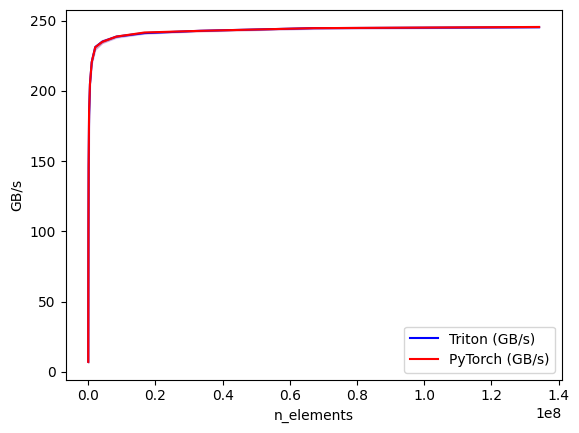

In [6]:
import triton.testing

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['n_elements'],
        x_vals=[2**i for i in range(12, 28)],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'PyTorch'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='Vector Addition: Triton vs PyTorch',
        args={},
    )
)
def benchmark(n_elements, provider):
    x = torch.randn(n_elements, device='cuda', dtype=torch.float32)
    y = torch.randn(n_elements, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: vector_add(x, y), quantiles=quantiles)
    elif provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)

    # GB/s: read x and y, write out — 3 tensors of float32 (4 bytes each)
    gbps = lambda ms: 3 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Vector addition is memory-bound at all input sizes — both Triton and PyTorch
hit ~ 245 GB/s at large sizes, close to T4's peak memory bandwidth (~ 300 GB/s).

Triton is slower at small sizes (n < 65536) due to kernel launch overhead.
At large sizes both implementations are identical — the bottleneck is hardware
memory bandwidth, not the kernel implementation.

## Section 2: Fused Softmax

Naive softmax requires 3 separate passes over the data — one to compute the max,
one to compute the exponentials, and one to normalize. Each pass reads and writes
from global memory, resulting in 6 total global memory operations.

This kernel fuses all 3 passes into one. The max and sum are computed in registers
without ever writing intermediate results to global memory, reducing global memory
traffic from 6 passes to 2 (one load, one store).

### Kernel Implementation

In [8]:
@triton.jit
def fused_softmax_kernel(
    x_ptr,              # pointer to input matrix
    out_ptr,            # pointer to output matrix
    stride,             # number of elements to skip to get to next row
    n_cols,             # number of columns (elements per row)
    BLOCK_SIZE: tl.constexpr,  # must be >= n_cols, power of 2
):
    # one program instance per row
    row_idx = tl.program_id(axis=0)
    row_ptr = x_ptr + row_idx * stride

    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_cols

    # load row, masking out-of-bounds with -inf so they don't affect max
    x = tl.load(row_ptr + offsets, mask=mask, other=float('-inf'))

    # subtract max for numerical stability before computing exp
    x = x - tl.max(x, axis=0)

    # compute numerically stable exp
    x = tl.exp(x)

    # normalize
    x = x / tl.sum(x, axis=0)

    # store result
    out_ptr_row = out_ptr + row_idx * stride
    tl.store(out_ptr_row + offsets, x, mask=mask)


def fused_softmax(x: torch.Tensor) -> torch.Tensor:
    n_rows, n_cols = x.shape
    # BLOCK_SIZE must be >= n_cols and a power of 2
    BLOCK_SIZE = triton.next_power_of_2(n_cols)
    out = torch.empty_like(x)
    # one program instance per row
    fused_softmax_kernel[(n_rows,)](
        x, out,
        x.stride(0),   # stride in elements, not bytes
        n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return out

### Correctness Check

In [20]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device='cuda')

triton_out = fused_softmax(x)
torch_out = torch.softmax(x, dim=1)

if torch.allclose(triton_out, torch_out, atol=1e-5):
    print('Correctness check passed')
else:
    print('Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

Correctness check passed


### Benchmark: Triton Fused Softmax vs PyTorch

Fused Softmax: Triton vs PyTorch:
   n_cols  Triton Fused (GB/s)  PyTorch (GB/s)
0   128.0            81.843273      181.540160
1   256.0           218.271450      215.578957
2   512.0           221.405396      217.818037
3  1024.0           228.398169      213.298609
4  2048.0           230.595635      212.779229
5  4096.0           230.570276      244.252512
6  8192.0           230.465760      249.153011


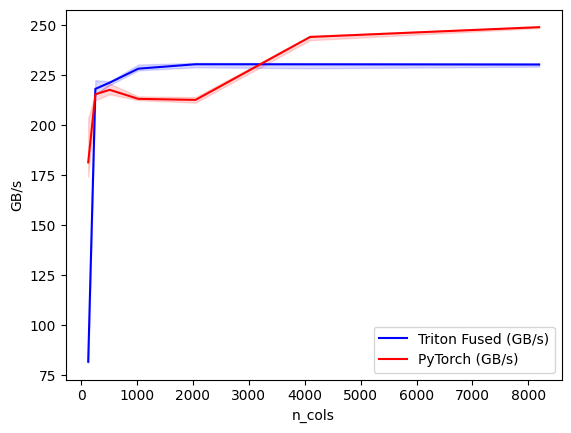

In [11]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['n_cols'],
        x_vals=[128, 256, 512, 1024, 2048, 4096, 8192],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton Fused', 'PyTorch'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='Fused Softmax: Triton vs PyTorch',
        args={'n_rows': 4096},
    )
)
def benchmark_softmax(n_rows, n_cols, provider):
    x = torch.randn(n_rows, n_cols, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: fused_softmax(x), quantiles=quantiles)
    elif provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.softmax(x, dim=1), quantiles=quantiles)

    # GB/s: read input once, write output once — 2 tensors
    gbps = lambda ms: 2 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark_softmax.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Triton fused softmax matches or beats PyTorch in the 256–2048 column range,
which covers typical transformer hidden dimensions. At small sizes (n_cols=128)
padding overhead hurts performance. At large sizes PyTorch's internal CUDA
implementation edges ahead.

The fusion benefit is real — eliminating intermediate global memory writes
keeps us near the T4 memory bandwidth ceiling (~230 GB/s) across the middle range.

## Section 3: Tiled Matrix Multiplication (GEMM)

Naive matrix multiplication recomputes every element of A and B repeatedly —
each output element reads an entire row of A and column of B from global memory.

Tiling fixes this: blocks of threads cooperatively load tiles of A and B into
shared memory (registers in Triton), reuse them across the K dimension, and
accumulate partial results. This dramatically increases arithmetic intensity
and pushes the kernel toward compute-bound rather than memory-bound.

### Kernel Implementation

In [15]:
@triton.jit
def tiled_gemm_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,   # strides for matrix A
    stride_bk, stride_bn,   # strides for matrix B
    stride_cm, stride_cn,   # strides for matrix C
    BLOCK_M: tl.constexpr,  # tile size along M dimension
    BLOCK_N: tl.constexpr,  # tile size along N dimension
    BLOCK_K: tl.constexpr,  # tile size along K dimension
):
    # which tile am I responsible for
    pid_m = tl.program_id(axis=0)
    pid_n = tl.program_id(axis=1)

    # row and column offsets for this tile
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    # pointers to first tile of A and B
    a_ptrs = a_ptr + (offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn)

    # accumulator in FP32 to prevent precision loss during accumulation
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    # iterate over K dimension in BLOCK_K chunks
    for k in range(0, (K + BLOCK_K - 1) // BLOCK_K):
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_K, other=0.0)

        # accumulate partial dot product — routes through Tensor Cores for FP16
        acc += tl.dot(a, b)

        # advance pointers to next K tile
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk

    # write output tile, cast back to FP16
    c = acc.to(tl.float16)
    offs_cm = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_cn = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    c_ptrs = c_ptr + offs_cm[:, None] * stride_cm + offs_cn[None, :] * stride_cn
    mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=mask)


def tiled_gemm(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    M, K = a.shape
    K, N = b.shape
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    grid = lambda meta: (triton.cdiv(M, meta['BLOCK_M']), triton.cdiv(N, meta['BLOCK_N']))
    tiled_gemm_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=64, BLOCK_N=64, BLOCK_K=32,
    )
    return c


### Correctness Check

In [21]:
torch.manual_seed(0)
M, K, N = 512, 512, 512
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

triton_out = tiled_gemm(a, b)
torch_out = torch.matmul(a, b)

if torch.allclose(triton_out, torch_out, atol=0.05):
    print('Correctness check passed')
else:
    print('Correctness check failed')
    print(f'Max difference: {(triton_out - torch_out).abs().max().item()}')

Correctness check passed


### Benchmark: Triton Tiled GEMM vs PyTorch

Tiled GEMM: Triton vs PyTorch:
        M  Triton Tiled GEMM (TFLOPS)  PyTorch (cuBLAS) (TFLOPS)
0   128.0                    0.099902                   0.428340
1   256.0                    0.575193                   2.759410
2   512.0                    1.927529                  13.378960
3  1024.0                    1.315654                  29.292390
4  2048.0                    1.145545                  23.963172
5  4096.0                    1.083275                  17.778286


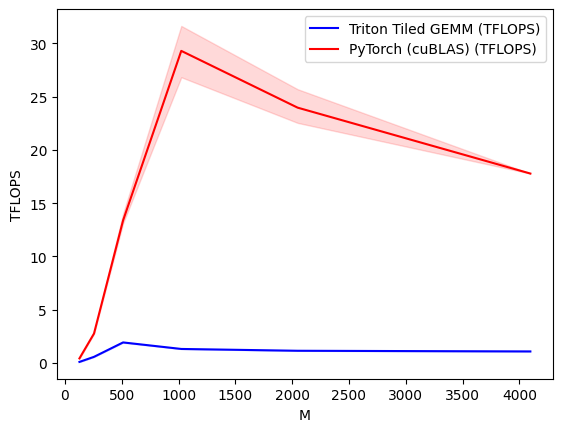

In [18]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['M'],
        x_vals=[128, 256, 512, 1024, 2048, 4096],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton Tiled GEMM', 'PyTorch (cuBLAS)'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='TFLOPS',
        plot_name='Tiled GEMM: Triton vs PyTorch',
        args={},
    )
)
def benchmark_gemm(M, provider):
    # square matrices M x M
    N, K = M, M
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: tiled_gemm(a, b), quantiles=quantiles)
    elif provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)

    # TFLOPS: 2 * M * N * K flops for matrix multiply
    tflops = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return tflops(ms), tflops(max_ms), tflops(min_ms)

benchmark_gemm.run(print_data=True, save_path=PLOTS_DIR)

### Results Analysis

Our tiled GEMM is significantly slower than PyTorch (cuBLAS) at all sizes.
cuBLAS uses assembly-level tuned kernels, autotuned tile sizes, and software
pipelining. Our kernel uses fixed tile sizes with no pipelining.

The gap is not a flaw in tiling as a strategy — it is a gap in implementation
maturity. A production Triton GEMM with autotuning and num_stages closes most
of this gap. The value here is understanding WHY tiling works, not beating cuBLAS.

## Summary

Three kernels, three different stories:

**Vector Addition** — Triton matches PyTorch at large sizes (~245 GB/s), both
hitting T4's memory bandwidth ceiling. At small sizes kernel launch overhead
dominates. Memory-bound at all sizes.

**Fused Softmax** — Triton wins in the 256–2048 column range by eliminating
intermediate global memory writes. Fusion is a real and measurable benefit
for memory-bound operations.

**Tiled GEMM** — PyTorch (cuBLAS) dominates. Our teaching implementation
uses fixed tile sizes with no autotuning or pipelining. The value is
understanding tiling as a concept, not beating cuBLAS.

**Key takeaway:** The roofline model predicts all three results. Memory-bound
ops benefit from fusion (softmax). Compute-bound ops require assembly-level
tuning to compete with cuBLAS (GEMM). Knowing which regime you are in is
the first step to knowing where to optimize.